## Original Data


Truncation FOC check | Dataset1_outliers_ready.csv  n=104113  mean=7.4102
Applying Small Constant Additive Effect: 0.1482

RESULTS:
  Empirical SNR Argmax (C_tproxy): 0.1530
  Theoretical Root (C_foc):      Not found in this range. (Distribution may lack interior maximum).


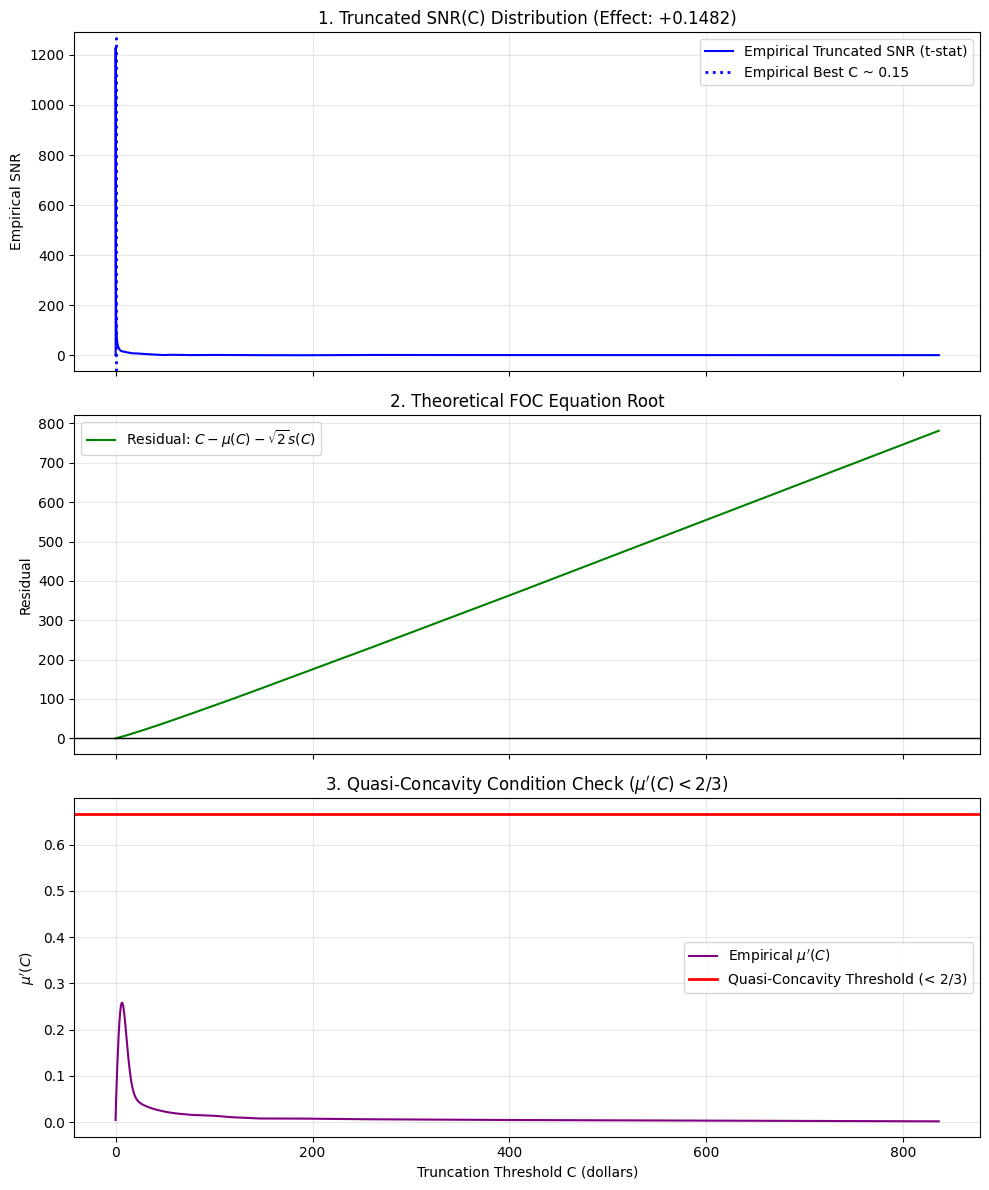

In [11]:
import pandas as pd
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt

# =====================================================================
# 1. TRUNCATION STATISTICS HELPERS
# =====================================================================
def trunc_stats(x, c):
    """Returns the mean, variance, and std dev of data strictly <= c."""
    valid = x[x <= c]
    if len(valid) < 2:
        return np.nan, np.nan, np.nan
    m = valid.mean()
    v = valid.var(ddof=1)
    return m, v, np.sqrt(v)

def residual_trunc(x, c):
    """
    Evaluates the theoretical fixed-point condition for Truncation:
    C = \mu(C) + \sqrt{2} * s(C)  --> Residual = C - \mu(C) - \sqrt{2} * s(C)
    """
    m, v, s = trunc_stats(x, c)
    if np.isnan(m): 
        return np.nan
    return c - m - np.sqrt(2) * s

def t_ratio_proxy_trunc(c, delta, xc, xt_raw):
    """
    Empirical SNR (t-statistic) for a TRUNCATED A/B test.
    We apply the effect FIRST, then drop all users above C.
    """
    gc = xc[xc <= c]
    gt_raw = xt_raw + delta
    gt = gt_raw[gt_raw <= c]
    
    n0, n1 = len(gc), len(gt)
    if n0 < 2 or n1 < 2:
        return 0.0
        
    m0, m1 = gc.mean(), gt.mean()
    v0, v1 = gc.var(ddof=1), gt.var(ddof=1)
    
    se = np.sqrt(v0/n0 + v1/n1)
    if se > 0:
        return abs(m1 - m0) / se
    return 0.0

def smooth_mu_prime(x, c_arr):
    """
    Calculates \mu'(C) using the theoretical identity: \mu'(C) = r(C)(C - \mu(C))
    We use a Gaussian KDE to estimate the density p(C) smoothly.
    """
    kde = stats.gaussian_kde(x)
    p_c = kde.evaluate(c_arr) # PDF
    P_c = np.array([np.mean(x <= c) for c in c_arr]) # CDF
    
    mu_primes = []
    for i, c in enumerate(c_arr):
        m, _, _ = trunc_stats(x, c)
        if P_c[i] > 0 and not np.isnan(m):
            r_c = p_c[i] / P_c[i] # Reverse hazard rate
            mu_primes.append(r_c * (c - m))
        else:
            mu_primes.append(np.nan)
    return np.array(mu_primes)

def assign_split(x, rng):
    n = x.size
    idx_t = rng.random(n) < 0.5
    return x[~idx_t], x[idx_t]

# =====================================================================
# 2. EXECUTION & ANALYSIS
# =====================================================================
file_path = '/Users/denghaonan/Desktop/capping/capping_code/Dataset1_outliers_ready.csv'

try:
    df = pd.read_csv(file_path)
    x = df['REVENUE'].values.astype(float)
    name = file_path.split('/')[-1]
    mu = float(x.mean())
    
    # 2.0 Test a "Small" Constant Effect (e.g., 2% lift) as assumed in the derivation
    delta = mu * 0.02 
    print(f"\n{'='*80}\nTruncation FOC check | {name}  n={x.size}  mean={mu:.4f}")
    print(f"Applying Small Constant Additive Effect: {delta:.4f}")

    # Set up evaluation grid (Focusing on the 60th to 99.9th percentiles)
    pct_grid = np.linspace(0.60, 0.999, 200)
    cs = np.quantile(x, pct_grid)
    
    # Calculate Theoretical Residuals
    res = np.array([residual_trunc(x, c) for c in cs])
    
    # Calculate Empirical SNR (T-Proxy)
    rng = np.random.default_rng(42)
    xc_s, xt0 = assign_split(x, rng)
    tvals = np.array([t_ratio_proxy_trunc(c, delta, xc_s, xt0) for c in cs])
    
    # Calculate mu'(C) check for Quasi-concavity
    mu_primes = smooth_mu_prime(x, cs)

    # Find Empirical Maximum SNR
    k_opt = int(np.argmax(tvals))
    c_topt = float(cs[k_opt])
    
    # Find Theoretical Root (where Residual crosses 0)
    c_foc = None
    for i in range(len(cs) - 1):
        if res[i] * res[i + 1] < 0:
            c_foc, _ = optimize.brentq(
                lambda z: residual_trunc(x, z),
                float(cs[i]),
                float(cs[i + 1]),
                full_output=True,
            )
            break
            
    print(f"\nRESULTS:")
    print(f"  Empirical SNR Argmax (C_tproxy): {c_topt:.4f}")
    if c_foc:
        print(f"  Theoretical Root (C_foc):      {c_foc:.4f}")
        m_foc, v_foc, s_foc = trunc_stats(x, c_foc)
        print(f"     -> At root: mu(C)={m_foc:.4f}, s(C)={s_foc:.4f}")
    else:
        print(f"  Theoretical Root (C_foc):      Not found in this range. (Distribution may lack interior maximum).")

    # =====================================================================
    # 3. PLOTTING (Addressing 2.1 and 2.2)
    # =====================================================================
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Plot 2.1a: The distribution of SNR(C)
    axs[0].plot(cs, tvals, color='blue', label='Empirical Truncated SNR (t-stat)')
    axs[0].axvline(c_topt, color='blue', ls=':', lw=2, label=f'Empirical Best C ~ {c_topt:.2f}')
    if c_foc:
        axs[0].axvline(c_foc, color='red', ls='--', lw=2, label=f'Theoretical FOC C ~ {c_foc:.2f}')
    axs[0].set_ylabel('Empirical SNR')
    axs[0].set_title(f'1. Truncated SNR(C) Distribution (Effect: +{delta:.4f})')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Plot 2.1b: The Theoretical FOC Residual
    axs[1].plot(cs, res, color='green', label=r'Residual: $C - \mu(C) - \sqrt{2}s(C)$')
    axs[1].axhline(0, color='k', lw=1)
    if c_foc:
        axs[1].axvline(c_foc, color='red', ls='--', lw=2)
    axs[1].set_ylabel('Residual')
    axs[1].set_title(r'2. Theoretical FOC Equation Root')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Plot 2.2: The Quasi-Concavity Condition
    axs[2].plot(cs, mu_primes, color='purple', label=r'Empirical $\mu^\prime(C)$')
    axs[2].axhline(2/3, color='red', lw=2, label='Quasi-Concavity Threshold (< 2/3)')
    if c_foc:
        axs[2].axvline(c_foc, color='red', ls='--', lw=2)
        
        # Check the exact value at the root
        idx_foc = np.argmin(np.abs(cs - c_foc))
        val_at_root = mu_primes[idx_foc]
        axs[2].plot(c_foc, val_at_root, marker='o', color='red')
        axs[2].annotate(f"$\mu'(C^*)$ = {val_at_root:.3f}", (c_foc, val_at_root), textcoords="offset points", xytext=(10,10), ha='left')

    axs[2].set_xlabel('Truncation Threshold C (dollars)')
    axs[2].set_ylabel(r'$\mu^\prime(C)$')
    axs[2].set_title(r'3. Quasi-Concavity Condition Check ($\mu^\prime(C) < 2/3$)')
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Failed to run: {e}")

## Dummy Data

## Constant Effect


Truncation FOC check | Dataset1_outliers_ready.csv (synthetic REVENUE)  n=104113  mean=100.0684
Applying Small Constant Additive Effect: 2.0014

RESULTS:
  Empirical SNR Argmax (C_tproxy): 143.0807
  Theoretical Root (C_foc):      109.2194
     -> At root: mu(C)=87.9348, s(C)=15.0505


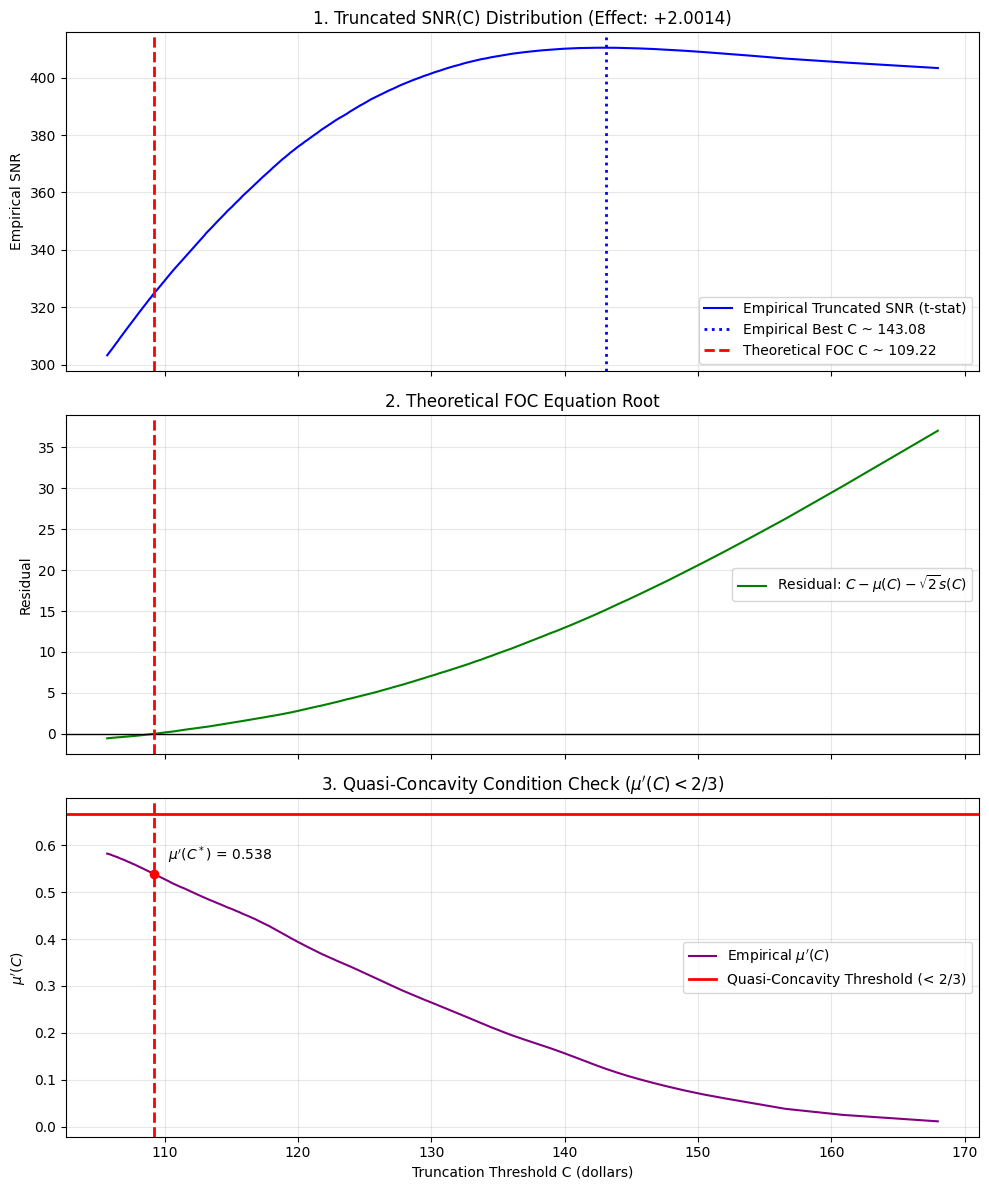

In [15]:
import pandas as pd
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt

# =====================================================================
# 1. TRUNCATION STATISTICS HELPERS
# =====================================================================
def trunc_stats(x, c):
    """Returns the mean, variance, and std dev of data strictly <= c."""
    valid = x[x <= c]
    if len(valid) < 2:
        return np.nan, np.nan, np.nan
    m = valid.mean()
    v = valid.var(ddof=1)
    return m, v, np.sqrt(v)

def residual_trunc(x, c):
    """
    Evaluates the theoretical fixed-point condition for Truncation:
    C = \mu(C) + \sqrt{2} * s(C)  --> Residual = C - \mu(C) - \sqrt{2} * s(C)
    """
    m, v, s = trunc_stats(x, c)
    if np.isnan(m): 
        return np.nan
    return c - m - np.sqrt(2) * s

def t_ratio_proxy_trunc(c, delta, xc, xt_raw):
    """
    Empirical SNR (t-statistic) for a TRUNCATED A/B test.
    We apply the effect FIRST, then drop all users above C.
    """
    gc = xc[xc <= c]
    gt_raw = xt_raw + delta
    gt = gt_raw[gt_raw <= c]
    
    n0, n1 = len(gc), len(gt)
    if n0 < 2 or n1 < 2:
        return 0.0
        
    m0, m1 = gc.mean(), gt.mean()
    v0, v1 = gc.var(ddof=1), gt.var(ddof=1)
    
    se = np.sqrt(v0/n0 + v1/n1)
    if se > 0:
        return abs(m1 - m0) / se
    return 0.0

def smooth_mu_prime(x, c_arr):
    """
    Calculates \mu'(C) using the theoretical identity: \mu'(C) = r(C)(C - \mu(C))
    We use a Gaussian KDE to estimate the density p(C) smoothly.
    """
    kde = stats.gaussian_kde(x)
    p_c = kde.evaluate(c_arr) # PDF
    P_c = np.array([np.mean(x <= c) for c in c_arr]) # CDF
    
    mu_primes = []
    for i, c in enumerate(c_arr):
        m, _, _ = trunc_stats(x, c)
        if P_c[i] > 0 and not np.isnan(m):
            r_c = p_c[i] / P_c[i] # Reverse hazard rate
            mu_primes.append(r_c * (c - m))
        else:
            mu_primes.append(np.nan)
    return np.array(mu_primes)

def assign_split(x, rng):
    n = x.size
    idx_t = rng.random(n) < 0.5
    return x[~idx_t], x[idx_t]

# =====================================================================
# 2. EXECUTION & ANALYSIS
# =====================================================================
file_path = '/Users/denghaonan/Desktop/capping/capping_code/Dataset1_outliers_ready.csv'

try:
    # Mimic Dataset1 only in n and Group counts; REVENUE is fully synthetic (not tied to CSV mean/std).
    _ref = pd.read_csv(file_path)
    n = len(_ref)
    n_a = int((_ref['Group'] == 'A').sum())
    n_b = n - n_a

    # Near-symmetric positive revenue: truncated Gaussian with mean several SDs above 0 (effectively
    # normal), avoiding heavy-tailed highly skewed draws like lognormal.
    _syn_mean = 100.0
    _syn_std = 22.0
    _a = (0.0 - _syn_mean) / _syn_std

    rng_syn = np.random.default_rng(42)
    revenue = stats.truncnorm.rvs(_a, np.inf, loc=_syn_mean, scale=_syn_std, size=n, random_state=rng_syn)

    groups = np.array(['A'] * n_a + ['B'] * n_b)
    rng_syn.shuffle(groups)
    df = pd.DataFrame(
        {'User_ID': np.arange(1, n + 1), 'Group': groups, 'REVENUE': revenue}
    )

    x = df['REVENUE'].values.astype(float)
    name = file_path.split('/')[-1] + ' (synthetic REVENUE)'
    mu = float(x.mean())
    
    # 2.0 Test a "Small" Constant Effect (e.g., 2% lift) as assumed in the derivation
    delta = mu * 0.02 
    print(f"\n{'='*80}\nTruncation FOC check | {name}  n={x.size}  mean={mu:.4f}")
    print(f"Applying Small Constant Additive Effect: {delta:.4f}")

    # Set up evaluation grid (Focusing on the 60th to 99.9th percentiles)
    pct_grid = np.linspace(0.60, 0.999, 200)
    cs = np.quantile(x, pct_grid)
    
    # Calculate Theoretical Residuals
    res = np.array([residual_trunc(x, c) for c in cs])
    
    # Calculate Empirical SNR (T-Proxy)
    rng = np.random.default_rng(42)
    xc_s, xt0 = assign_split(x, rng)
    tvals = np.array([t_ratio_proxy_trunc(c, delta, xc_s, xt0) for c in cs])
    
    # Calculate mu'(C) check for Quasi-concavity
    mu_primes = smooth_mu_prime(x, cs)

    # Find Empirical Maximum SNR
    k_opt = int(np.argmax(tvals))
    c_topt = float(cs[k_opt])
    
    # Find Theoretical Root (where Residual crosses 0)
    c_foc = None
    for i in range(len(cs) - 1):
        if res[i] * res[i + 1] < 0:
            c_foc, _ = optimize.brentq(
                lambda z: residual_trunc(x, z),
                float(cs[i]),
                float(cs[i + 1]),
                full_output=True,
            )
            break
            
    print(f"\nRESULTS:")
    print(f"  Empirical SNR Argmax (C_tproxy): {c_topt:.4f}")
    if c_foc:
        print(f"  Theoretical Root (C_foc):      {c_foc:.4f}")
        m_foc, v_foc, s_foc = trunc_stats(x, c_foc)
        print(f"     -> At root: mu(C)={m_foc:.4f}, s(C)={s_foc:.4f}")
    else:
        print(f"  Theoretical Root (C_foc):      Not found in this range. (Distribution may lack interior maximum).")

    # =====================================================================
    # 3. PLOTTING (Addressing 2.1 and 2.2)
    # =====================================================================
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    # Plot 2.1a: The distribution of SNR(C)
    axs[0].plot(cs, tvals, color='blue', label='Empirical Truncated SNR (t-stat)')
    axs[0].axvline(c_topt, color='blue', ls=':', lw=2, label=f'Empirical Best C ~ {c_topt:.2f}')
    if c_foc:
        axs[0].axvline(c_foc, color='red', ls='--', lw=2, label=f'Theoretical FOC C ~ {c_foc:.2f}')
    axs[0].set_ylabel('Empirical SNR')
    axs[0].set_title(f'1. Truncated SNR(C) Distribution (Effect: +{delta:.4f})')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Plot 2.1b: The Theoretical FOC Residual
    axs[1].plot(cs, res, color='green', label=r'Residual: $C - \mu(C) - \sqrt{2}s(C)$')
    axs[1].axhline(0, color='k', lw=1)
    if c_foc:
        axs[1].axvline(c_foc, color='red', ls='--', lw=2)
    axs[1].set_ylabel('Residual')
    axs[1].set_title(r'2. Theoretical FOC Equation Root')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Plot 2.2: The Quasi-Concavity Condition
    axs[2].plot(cs, mu_primes, color='purple', label=r'Empirical $\mu^\prime(C)$')
    axs[2].axhline(2/3, color='red', lw=2, label='Quasi-Concavity Threshold (< 2/3)')
    if c_foc:
        axs[2].axvline(c_foc, color='red', ls='--', lw=2)
        
        # Check the exact value at the root
        idx_foc = np.argmin(np.abs(cs - c_foc))
        val_at_root = mu_primes[idx_foc]
        axs[2].plot(c_foc, val_at_root, marker='o', color='red')
        axs[2].annotate(f"$\mu'(C^*)$ = {val_at_root:.3f}", (c_foc, val_at_root), textcoords="offset points", xytext=(10,10), ha='left')

    axs[2].set_xlabel('Truncation Threshold C (dollars)')
    axs[2].set_ylabel(r'$\mu^\prime(C)$')
    axs[2].set_title(r'3. Quasi-Concavity Condition Check ($\mu^\prime(C) < 2/3$)')
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Failed to run: {e}")

### Linear effect

Treatment rule (proportionate lift):

$$Y_i(1) - Y_i(0) = \alpha \, Y_i(0)$$

Optimal truncation threshold (FOC):

$$C^* = \mu(C^*) + \sqrt{2 \, v(C^*) \, \dfrac{C^*}{\mu(C^*)}}$$

Quasi-concavity condition:

$$\mu'(C^*) < \dfrac{\mu(C^*)(C^*+\mu(C^*))}{C^*\bigl(C^*+2\mu(C^*)\bigr)}$$

Below: same synthetic control distribution as above, multiplicative treatment $Y_i(1)=(1+\alpha)\,Y_i(0)$ with $\alpha = 0.02$.


Truncation FOC check (linear effect) | Dataset1_outliers_ready.csv (synthetic REVENUE, linear effect)  n=104113  mean=100.0684
Multiplicative lift: alpha=0.02  (Y_treated = (1+alpha) * Y_baseline)

RESULTS:
  Empirical SNR Argmax (C_tproxy): 143.0807
  Theoretical Root (C_foc):      121.7887
     -> At root: mu(C)=93.6621, quasi-concavity RHS=0.5360


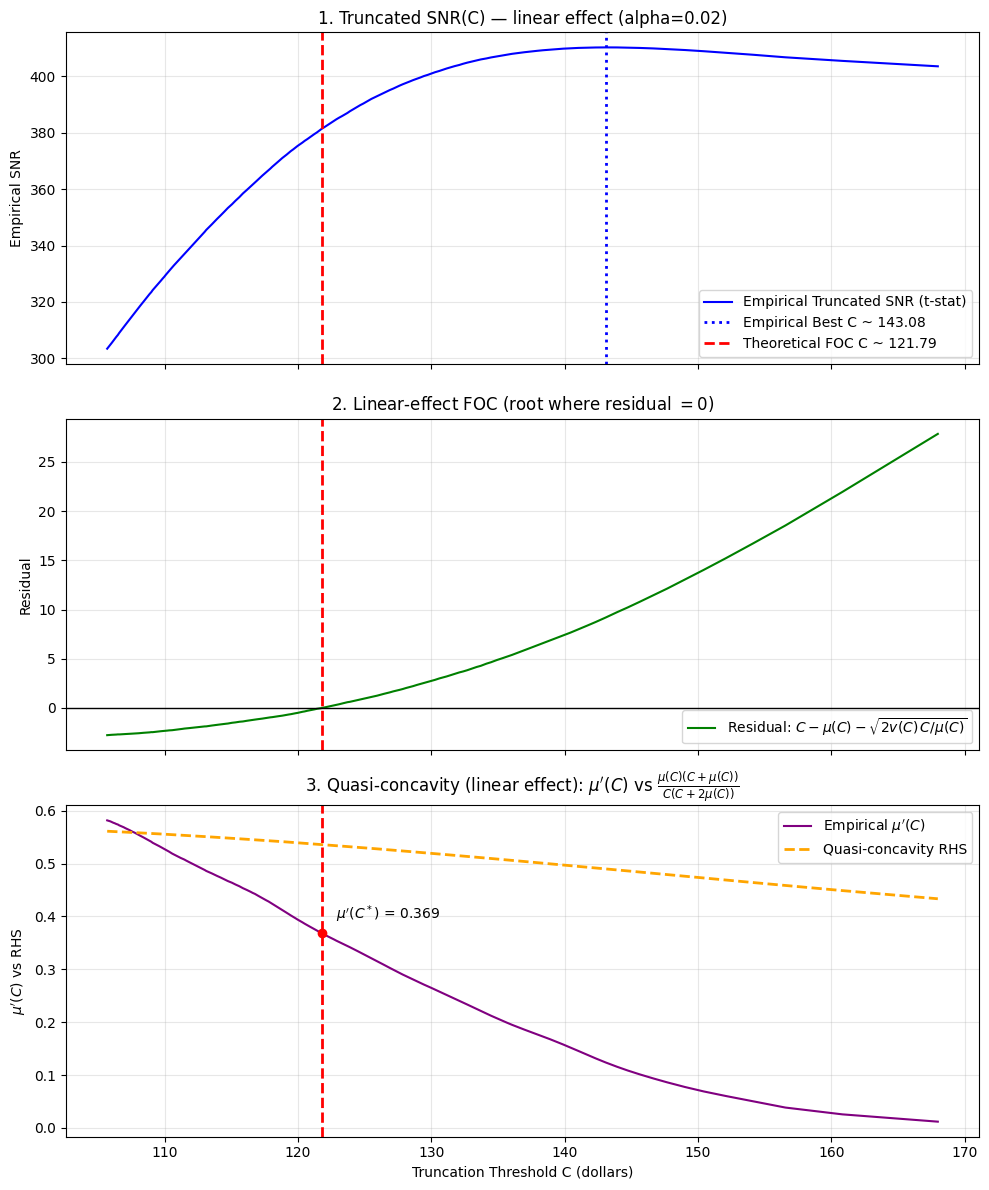

In [13]:
import pandas as pd
import numpy as np
from scipy import stats, optimize
import matplotlib.pyplot as plt

# =====================================================================
# 1. TRUNCATION STATISTICS HELPERS (linear-effect FOC uses v(C), μ(C))
# =====================================================================
def trunc_stats(x, c):
    """Returns the mean, variance, and std dev of data strictly <= c."""
    valid = x[x <= c]
    if len(valid) < 2:
        return np.nan, np.nan, np.nan
    m = valid.mean()
    v = valid.var(ddof=1)
    return m, v, np.sqrt(v)


def residual_trunc_linear(x, c):
    """
    Linear-effect FOC residual:
    C - μ(C) - sqrt(2 v(C) * C / μ(C))
    """
    m, v, s = trunc_stats(x, c)
    if np.isnan(m) or m <= 1e-12:
        return np.nan
    inner = 2.0 * v * (c / m)
    if inner < 0:
        inner = 0.0
    return c - m - np.sqrt(inner)


def quasi_threshold_linear(c, mu_c):
    """RHS of quasi-concavity: μ(C)(C+μ(C)) / (C(C+2μ(C)))."""
    if np.isnan(mu_c) or abs(c) < 1e-15:
        return np.nan
    den = c * (c + 2.0 * mu_c)
    if abs(den) < 1e-15:
        return np.nan
    return mu_c * (c + mu_c) / den


def t_ratio_proxy_trunc_linear(c, alpha, xc, xt0):
    """
    Empirical SNR for truncated A/B test under Y(1) = (1+α) Y(0).
    Effect applied first, then truncate at C.
    """
    gc = xc[xc <= c]
    gt_raw = xt0 * (1.0 + alpha)
    gt = gt_raw[gt_raw <= c]

    n0, n1 = len(gc), len(gt)
    if n0 < 2 or n1 < 2:
        return 0.0

    m0, m1 = gc.mean(), gt.mean()
    v0, v1 = gc.var(ddof=1), gt.var(ddof=1)

    se = np.sqrt(v0 / n0 + v1 / n1)
    if se > 0:
        return abs(m1 - m0) / se
    return 0.0


def smooth_mu_prime(x, c_arr):
    kde = stats.gaussian_kde(x)
    p_c = kde.evaluate(c_arr)
    P_c = np.array([np.mean(x <= c) for c in c_arr])

    mu_primes = []
    for i, c in enumerate(c_arr):
        m, _, _ = trunc_stats(x, c)
        if P_c[i] > 0 and not np.isnan(m):
            r_c = p_c[i] / P_c[i]
            mu_primes.append(r_c * (c - m))
        else:
            mu_primes.append(np.nan)
    return np.array(mu_primes)


def assign_split(x, rng):
    n = x.size
    idx_t = rng.random(n) < 0.5
    return x[~idx_t], x[idx_t]


# =====================================================================
# 2. EXECUTION & ANALYSIS — LINEAR (MULTIPLICATIVE) EFFECT
# =====================================================================
file_path = '/Users/denghaonan/Desktop/capping/capping_code/Dataset1_outliers_ready.csv'

try:
    _ref = pd.read_csv(file_path)
    n = len(_ref)
    n_a = int((_ref['Group'] == 'A').sum())
    n_b = n - n_a

    _syn_mean = 100.0
    _syn_std = 22.0
    _a = (0.0 - _syn_mean) / _syn_std

    rng_syn = np.random.default_rng(42)
    revenue = stats.truncnorm.rvs(_a, np.inf, loc=_syn_mean, scale=_syn_std, size=n, random_state=rng_syn)

    groups = np.array(['A'] * n_a + ['B'] * n_b)
    rng_syn.shuffle(groups)
    df = pd.DataFrame(
        {'User_ID': np.arange(1, n + 1), 'Group': groups, 'REVENUE': revenue}
    )

    x = df['REVENUE'].values.astype(float)
    name = file_path.split('/')[-1] + ' (synthetic REVENUE, linear effect)'
    mu = float(x.mean())

    alpha = 0.02
    print(f"\n{'='*80}\nTruncation FOC check (linear effect) | {name}  n={x.size}  mean={mu:.4f}")
    print(f"Multiplicative lift: alpha={alpha}  (Y_treated = (1+alpha) * Y_baseline)")

    pct_grid = np.linspace(0.60, 0.999, 200)
    cs = np.quantile(x, pct_grid)

    res = np.array([residual_trunc_linear(x, c) for c in cs])

    rng = np.random.default_rng(42)
    xc_s, xt0 = assign_split(x, rng)
    tvals = np.array([t_ratio_proxy_trunc_linear(c, alpha, xc_s, xt0) for c in cs])

    mu_primes = smooth_mu_prime(x, cs)

    mu_at_c = np.array([trunc_stats(x, c)[0] for c in cs])
    quasi_rhs = np.array([quasi_threshold_linear(c, m) for c, m in zip(cs, mu_at_c)])

    k_opt = int(np.argmax(tvals))
    c_topt = float(cs[k_opt])

    c_foc = None
    for i in range(len(cs) - 1):
        if np.isfinite(res[i]) and np.isfinite(res[i + 1]) and res[i] * res[i + 1] < 0:
            c_foc, _ = optimize.brentq(
                lambda z: residual_trunc_linear(x, z),
                float(cs[i]),
                float(cs[i + 1]),
                full_output=True,
            )
            break

    print(f"\nRESULTS:")
    print(f"  Empirical SNR Argmax (C_tproxy): {c_topt:.4f}")
    if c_foc:
        print(f"  Theoretical Root (C_foc):      {c_foc:.4f}")
        m_foc, v_foc, s_foc = trunc_stats(x, c_foc)
        thr_foc = quasi_threshold_linear(c_foc, m_foc)
        print(f"     -> At root: mu(C)={m_foc:.4f}, quasi-concavity RHS={thr_foc:.4f}")
    else:
        print(f"  Theoretical Root (C_foc):      Not found in this range.")

    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    axs[0].plot(cs, tvals, color='blue', label='Empirical Truncated SNR (t-stat)')
    axs[0].axvline(c_topt, color='blue', ls=':', lw=2, label=f'Empirical Best C ~ {c_topt:.2f}')
    if c_foc:
        axs[0].axvline(c_foc, color='red', ls='--', lw=2, label=f'Theoretical FOC C ~ {c_foc:.2f}')
    axs[0].set_ylabel('Empirical SNR')
    axs[0].set_title(f'1. Truncated SNR(C) — linear effect (alpha={alpha})')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    axs[1].plot(cs, res, color='green', label=r'Residual: $C - \mu(C) - \sqrt{2 v(C)\,C/\mu(C)}$')
    axs[1].axhline(0, color='k', lw=1)
    if c_foc:
        axs[1].axvline(c_foc, color='red', ls='--', lw=2)
    axs[1].set_ylabel('Residual')
    axs[1].set_title(r'2. Linear-effect FOC (root where residual $=0$)')
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    axs[2].plot(cs, mu_primes, color='purple', label=r"Empirical $\mu'(C)$")
    axs[2].plot(cs, quasi_rhs, color='orange', ls='--', lw=2, label=r'Quasi-concavity RHS')
    if c_foc:
        axs[2].axvline(c_foc, color='red', ls='--', lw=2)
        idx_foc = np.argmin(np.abs(cs - c_foc))
        val_at_root = mu_primes[idx_foc]
        thr_at = quasi_rhs[idx_foc]
        axs[2].plot(c_foc, val_at_root, marker='o', color='red')
        axs[2].annotate(r"$\mu'(C^*)$" + f" = {val_at_root:.3f}", (c_foc, val_at_root), textcoords="offset points", xytext=(10, 10), ha='left')

    axs[2].set_xlabel('Truncation Threshold C (dollars)')
    axs[2].set_ylabel(r"$\mu'(C)$ vs RHS")
    axs[2].set_title(r'3. Quasi-concavity (linear effect): $\mu^\prime(C)$ vs $\frac{\mu(C)(C+\mu(C))}{C(C+2\mu(C))}$')
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Failed to run: {e}")
